In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from lmfit import Model

In [4]:
def field_model(z, Br, R, L, z0):
    Z_eff = z + z0 
    term1 = (Z_eff + L) / np.sqrt(R**2 + (Z_eff + L)**2)
    term2 = Z_eff / np.sqrt(R**2 + Z_eff**2)
    return (Br / 2) * (term1 - term2)

def field_deriv(z, Br, R, L, z0):
    Z = z + z0
    deriv_term1 = R**2 / (R**2 + (Z + L)**2)**(1.5)
    deriv_term2 = R**2 / (R**2 + Z**2)**(1.5)
    db_dz = (Br / 2) * (deriv_term1 - deriv_term2) 
    return db_dz

In [13]:
def plot_and_fit(df, label = '', units = 'mks', R=14.075, L=7.25): #R,L en mm
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=150)

    if units == 'mks':
        d = df['d [mm]'][:]
        B = df['B [mT]'][:]
        d_err = df['delta_d [mm]'][:]
        B_err = df['delta_B [mT]'][:]
        ax.set_xlabel(r'z [$mm$]', fontweight='bold')
        ax.set_ylabel(r'H [$mT$]', fontweight='bold')
        
    elif units == 'cgs':
        d = df['d [cm]']*10
        B = df['B [G]'][:]
        d_err = df['delta_d [cm]']*10
        B_err = df['delta_B [G]'][:]
        ax.set_xlabel(r'z [$mm$]', fontweight='bold')
        ax.set_ylabel(r'H [$G$]', fontweight='bold')

    ax.errorbar(d, B, xerr = d_err, yerr=B_err, fmt='ks', markersize=3, capsize=2, 
                elinewidth=0.4, markeredgecolor='black', markerfacecolor='white', 
                label='Datos Experimentales', zorder=3)
    
    magnet_model = Model(field_model)

    params = magnet_model.make_params()
 
    params['R'].set(value=R, vary=False)
    params['L'].set(value=L, vary=False)
    params['Br'].set(value=12500, min=100, max=15000)
    params['z0'].set(value=0.05, min=-5.0, max=5.0)
    
    result = magnet_model.fit(B, params, z=d, method='dual_annealing')

    Br_fit = result.params['Br'].value
    Br_error = result.params['Br'].stderr
    
    z0_fit = result.params['z0'].value
    z0_error = result.params['z0'].stderr

    t = np.linspace(min(d), max(d), 1000)
    B_fit = field_model(t, Br = Br_fit, R=R, L=L, z0 = z0_fit)
    ax.plot(t, B_fit, linewidth = 0.6,color="blue", label = 'Ajuste Numérico', zorder =2)
    ax.set_title('Imán NdFeB. Campo Magnético', pad=10)

    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', frameon=True)
    
    plt.tight_layout()
    plt.savefig('graphs/magnet_' + label +'_characteristic_curve.png', bbox_inches='tight')
    plt.show()

    fig, bx = plt.subplots(figsize=(4, 3), dpi=150)
    
    window = 11
    poly = 3

    dd = d[1] - d[0]
    dB_dd_numerical = savgol_filter(B, window_length=window, polyorder=poly, deriv=1, delta=dd)

    bx.errorbar(d, dB_dd_numerical, fmt='ks', markersize=3, capsize=2, 
                elinewidth=0.4, markeredgecolor='black', markerfacecolor='white', 
                label='Derivada Numérica', zorder=3)

    dB_dd_analytical = field_deriv(t, Br=Br_fit, R=R, L=L, z0=z0_fit)
    bx.plot(t,dB_dd_analytical, linewidth = 0.6,color="blue", label = 'Derivada Analítica', zorder =2)

    if units == 'mks':
        bx.set_xlabel(r'z [$mm$]', fontweight='bold')
        bx.set_ylabel(r'dH/dz[$T/m$]', fontweight='bold')
        
    elif units == 'cgs':
        bx.set_xlabel(r'z [$mm$]', fontweight='bold')
        bx.set_ylabel(r'dH/dz [$G/mm$]', fontweight='bold')
        
    bx.set_title('Imán NdFeB. Derivada del Campo', pad=10)

    bx.grid(True, which='both', linestyle='--', alpha=0.5)
    bx.legend(loc='lower right', frameon=True)
    
    plt.tight_layout()
    plt.savefig('graphs/magnet_' + label + '_numerical_derivative.png', bbox_inches='tight')
    plt.show()

    print(result.fit_report())

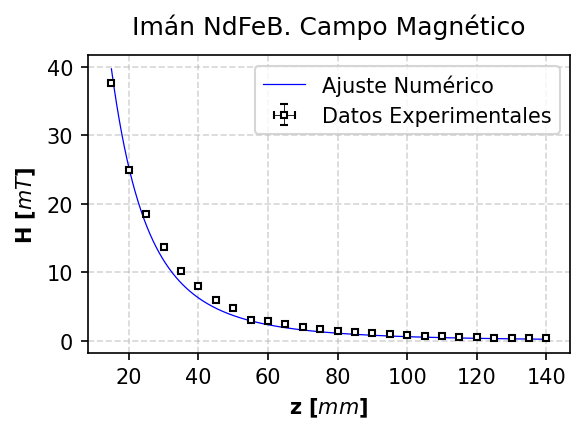

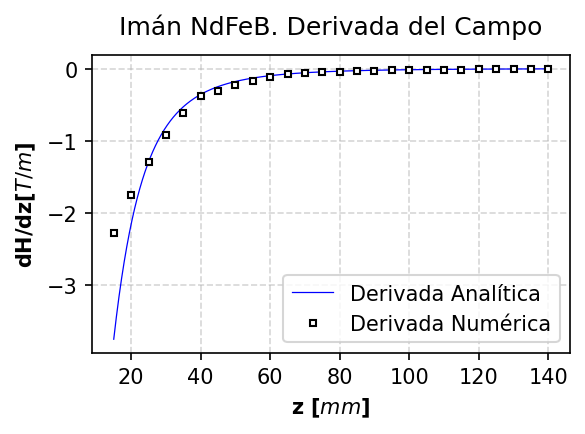

[[Model]]
    Model(field_model)
[[Fit Statistics]]
    # fitting method   = dual_annealing
    # function evals   = 4031
    # data points      = 26
    # variables        = 2
    chi-square         = 20.1110724
    reduced chi-square = 0.83796135
    Akaike info crit   = -2.67747624
    Bayesian info crit = -0.16128317
    R-squared          = 0.99007358
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    Br:  1123.51880 (init = 12500)
    R:   14.075 (fixed)
    L:   7.25 (fixed)
    z0:  5.00000000 (init = 0.05)


In [14]:
df = pd.read_csv('data/nb_magnet_data_11_02_2026_1.csv')
plot_and_fit(df, '11_02_2026_1', units = 'mks')

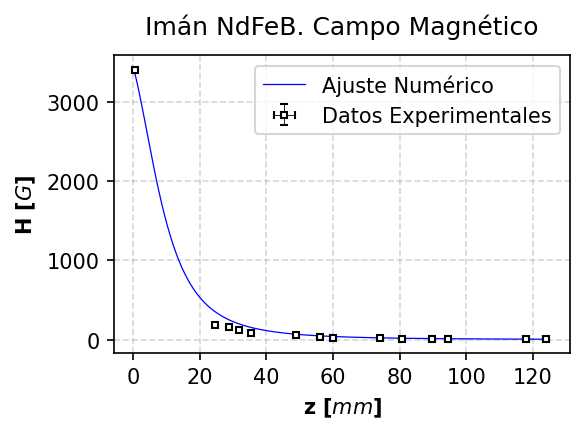

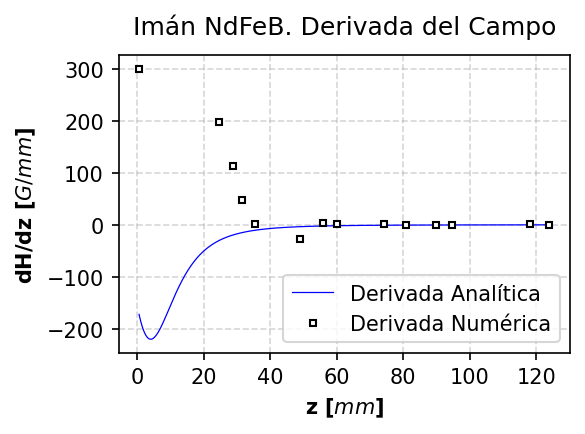

[[Model]]
    Model(field_model)
[[Fit Statistics]]
    # fitting method   = dual_annealing
    # function evals   = 4073
    # data points      = 14
    # variables        = 2
    chi-square         = 50404.4031
    reduced chi-square = 4200.36693
    Akaike info crit   = 118.642871
    Bayesian info crit = 119.920985
    R-squared          = 0.99519617
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    Br:  15000.0000 (init = 12500)
    R:   14.075 (fixed)
    L:   7.25 (fixed)
    z0: -0.05943368 (init = 0.05)


In [15]:
df1 = pd.read_csv('data/nb_magnet_data_16_02_2026_1.csv')
plot_and_fit(df1, '16_02_2026_1', units = 'cgs')

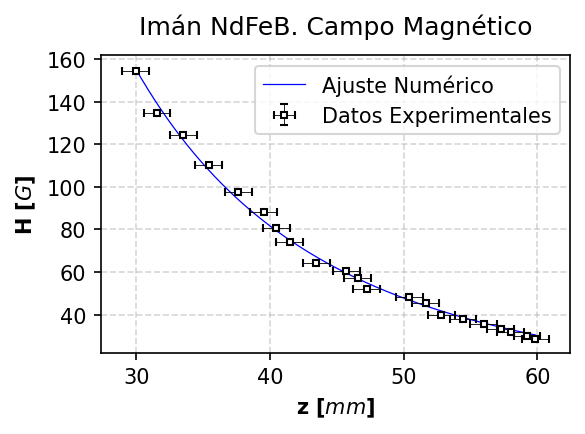

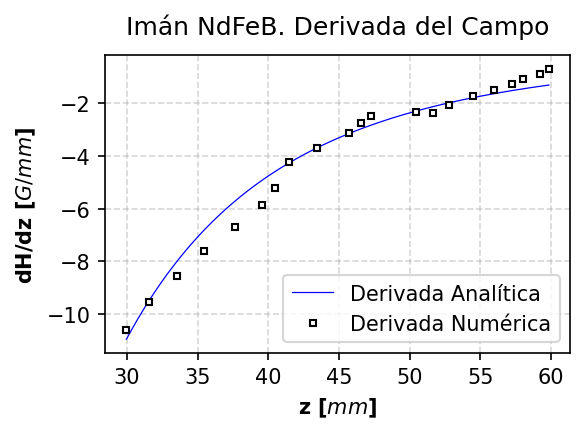

[[Model]]
    Model(field_model)
[[Fit Statistics]]
    # fitting method   = dual_annealing
    # function evals   = 4091
    # data points      = 21
    # variables        = 2
    chi-square         = 103.832503
    reduced chi-square = 5.46486858
    Akaike info crit   = 37.5633889
    Bayesian info crit = 39.6524338
    R-squared          = 0.99629038
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    Br:  13750.3943 (init = 12500)
    R:   14.075 (fixed)
    L:   7.25 (fixed)
    z0:  3.95673554 (init = 0.05)


In [16]:
df2 = pd.read_csv('data/nb_magnet_data_16_02_2026_2.csv')
df2 = df2.iloc[1:, :4].reset_index(drop=True)
plot_and_fit(df2, '16_02_2026_2', units = 'cgs')

In [56]:
field_model(z=27.47, Br= 13750.8020, R=14.075, L=7.25, z0=3.95718064)

np.float64(186.0498675140882)

In [108]:
def plot_force(df, label = '', Br =  13750.3943, R=1.4075, L=0.725, z0=3.95718064, V = 1, n=0): #R,L en cm
    fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
    
    F = df['m [g]']*9.81*1E-3
    d = df['d [cm]']*1e3
    F_err = df['delta_m [g]']*9.81*1E-3
    d_err = df['delta_d [cm]']*1e3
    ax.set_xlabel(r'z [$mm$]', fontweight='bold')
    ax.set_ylabel(r'F [$mN$]', fontweight='bold')

    ax.errorbar(d, F*1e3, xerr = d_err, yerr=F_err*1e3, fmt='ks', markersize=3, capsize=2, 
                elinewidth=0.4, markeredgecolor='black', markerfacecolor='white', 
                label='Datos Experimentales', zorder=3)
    ax.plot(d, F*1e3, linewidth=0.4, color = 'k', zorder=3)

    ax.set_title('Experimento ' + label + '. Fuerza', pad=10)

    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', frameon=True)
    
    plt.tight_layout()
    plt.savefig('graphs/'+ label + '_force.png', bbox_inches='tight')
    plt.show()

    fig, bx = plt.subplots(figsize=(4, 3), dpi=150)
    
    H = field_model(d, Br, R, L, z0)
    dH = field_deriv(d, Br, R, L, z0)
    M = (F*10**5)/(V*dH)
    M_err = np.abs((F_err*10**5)/(V*dH))

    bx.set_xlabel(r'$H_z$ [$G$]', fontweight='bold')
    bx.set_ylabel(r'$\mu_0 M_z$ [$G$]', fontweight='bold')

    bx.errorbar(H, M, yerr=M_err, fmt='ks', markersize=3, capsize=2, 
                elinewidth=0.4, markeredgecolor='black', markerfacecolor='white', 
                label='Datos Experimentales', zorder=3)
    bx.plot(H, M, linewidth=0.4, color = 'k', zorder=3)

    bx.set_title('Experimento ' + label + '. Magnetización', pad=10)

    bx.grid(True, which='both', linestyle='--', alpha=0.5)
    bx.legend(loc='upper right', frameon=True)
    
    plt.tight_layout()
    plt.savefig('graphs/'+ label + '_magnetization.png', bbox_inches='tight')
    plt.show()
    

In [109]:
V = np.pi*(0.48**2)*0.115

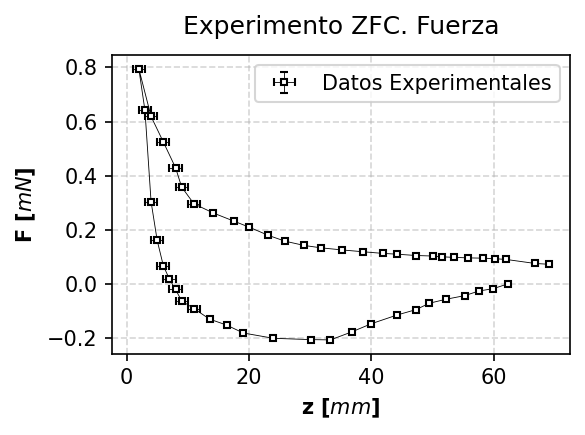

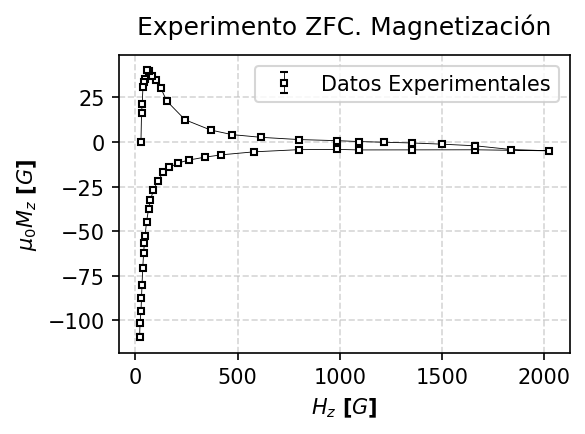

In [110]:
df = pd.read_csv('data/ZFC_superconductor_data.csv')
plot_force(df, 'ZFC', Br =  13750.3943, R=14.075, L=7.25, z0=3.95718064, V = V)

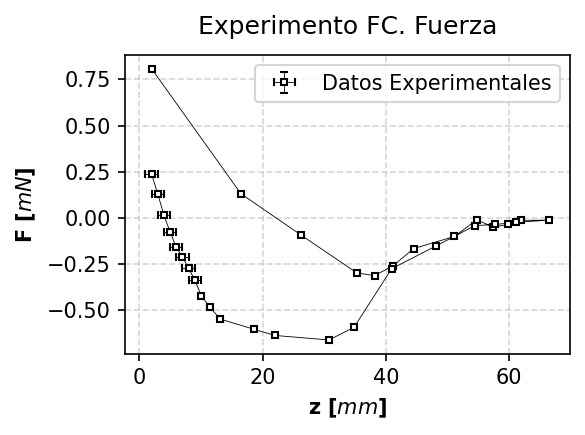

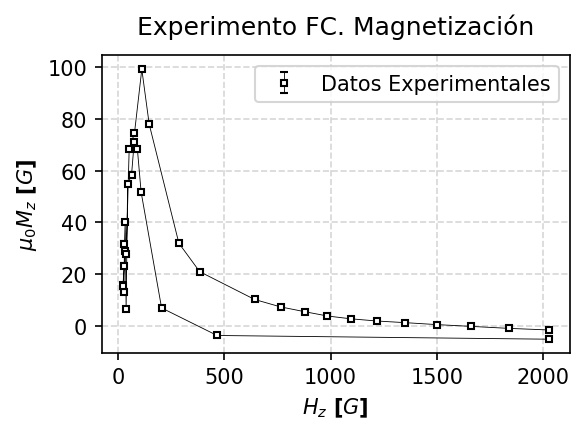

In [111]:
df = pd.read_csv('data/FC_superconductor_data.csv')
plot_force(df, 'FC',Br =  13750.3943, R=14.075, L=7.25, z0=3.95718064, V = V)